# Copulas and Risk Management Analysis

This notebook demonstrates the application of copulas in risk management, focusing on:
1. Fitting different copula models to financial data
2. Analyzing tail dependencies
3. Computing Value at Risk (VaR) and Expected Shortfall (ES)
4. Comparing different risk measures

## Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style
sns.set_palette('husl')

## 1. Data Preparation and Initial Analysis

First, we'll load and prepare our financial data, then perform some initial exploratory analysis.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Basic Statistics:
          CHFUSD=X     CHFEUR=X     CHFJPY=X     CHFCNY=X
count  5250.000000  5250.000000  5250.000000  5250.000000
mean      0.000087     0.000109     0.000150     0.000078
std       0.006697     0.005166     0.007168     0.009037
min      -0.088218    -0.084170    -0.079634    -0.090100
25%      -0.003133    -0.001592    -0.003099    -0.003606
50%      -0.000117     0.000060     0.000219    -0.000047
75%       0.003258     0.001668     0.003445     0.003684
max       0.192568     0.207255     0.179818     0.190648


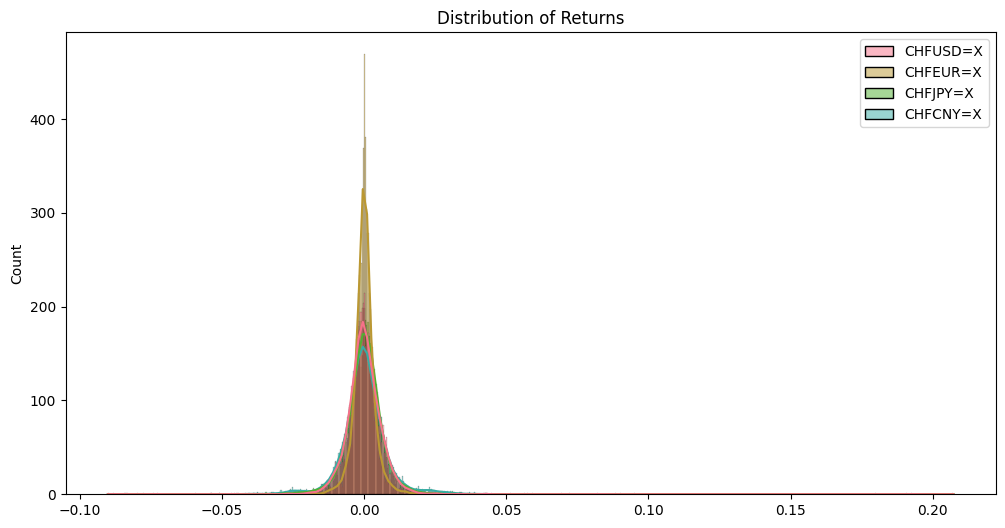

In [34]:
from yfinance import download

# Load data
TICKERS =['CHFUSD=X', 'CHFEUR=X', 'CHFJPY=X', 'CHFCNY=X']
df = pd.DataFrame()
for ticker in TICKERS:
    df[ticker] = download(ticker, start="1998-01-01")['Close']
returns = df.pct_change().dropna()

# Basic statistics
print("Basic Statistics:")
print(returns.describe())

# Plot returns distribution
plt.figure(figsize=(12, 6))
sns.histplot(returns, kde=True)
plt.title('Distribution of Returns')
plt.show()

In [ ]:
from copula.models.normal.gauss import GaussianCopula

# Convert returns to C-contiguous and correct dtype
returns = np.ascontiguousarray(returns.astype(np.double))
weights = np.array([0.25, 0.25, 0.25, 0.25], dtype=np.double)
copula = GaussianCopula(
    initial_weights=weights,
    returns=returns,
    size=100000
)

copula.fit()

print("VaR: ", copula.var)
print("CVaR: ", copula.cvar)

VaR:  -0.01581431853709916
CVaR:  -0.022258489448797936


## 2. Copula Fitting and Analysis

We'll implement and compare different copula models to capture the dependence structure between assets.

In [25]:
def fit_gaussian_copula(data):
    """Fit a Gaussian copula to the data."""
    # Transform to uniform margins using empirical CDF
    u = stats.rankdata(data, method='ordinal') / (len(data) + 1)
    
    # Transform to normal margins
    z = norm.ppf(u)
    
    # Compute correlation matrix
    rho = np.corrcoef(z.T)
    
    return rho

def fit_t_copula(data, df=5):
    """Fit a t-copula to the data."""
    # Transform to uniform margins
    u = stats.rankdata(data, method='ordinal') / (len(data) + 1)
    
    # Transform to t margins
    z = stats.t.ppf(u, df)

    # Compute correlation matrix
    rho = np.corrcoef(z.T)
    
    return rho, df

# Fit copulas to our data
gaussian_rho = fit_gaussian_copula(returns)
t_rho, t_df = fit_t_copula(returns)

print("Gaussian Copula Correlation Matrix:")
print(gaussian_rho)
print("\nT-Copula Correlation Matrix:")
print(t_rho)

Gaussian Copula Correlation Matrix:
nan

T-Copula Correlation Matrix:
nan


## 3. Tail Dependence Analysis

We'll analyze the tail dependencies between assets using different copula models.

In [ ]:
def compute_tail_dependence(rho, df=None):
    """Compute tail dependence coefficients."""
    if df is None:  # Gaussian copula
        return 0  # Gaussian copula has no tail dependence
    else:  # t-copula
        return 2 * stats.t.cdf(-np.sqrt((df + 1) * (1 - rho) / (1 + rho)), df + 1)

# Compute tail dependencies
print("Tail Dependence Analysis:")
print("Gaussian Copula (no tail dependence):", compute_tail_dependence(gaussian_rho[0,1]))
print("T-Copula:", compute_tail_dependence(t_rho[0,1], t_df))

## 4. Risk Measures

We'll implement and compare different risk measures including VaR and Expected Shortfall.

In [ ]:
def compute_var(returns, alpha=0.05):
    """Compute Value at Risk."""
    return np.percentile(returns, alpha * 100)

def compute_es(returns, alpha=0.05):
    """Compute Expected Shortfall."""
    var = compute_var(returns, alpha)
    return returns[returns <= var].mean()

# Compute risk measures
var_95 = compute_var(returns, 0.05)
es_95 = compute_es(returns, 0.05)

print("Risk Measures (95% confidence):")
print(f"VaR: {var_95:.4f}")
print(f"Expected Shortfall: {es_95:.4f}")

## 5. Portfolio Risk Analysis

We'll analyze portfolio risk using different copula models and risk measures.

In [ ]:
def simulate_portfolio_returns(weights, returns, n_simulations=10000):
    """Simulate portfolio returns using copula models."""
    # Generate correlated random numbers
    z = np.random.multivariate_normal(np.zeros(len(weights)), gaussian_rho, n_simulations)
    u = norm.cdf(z)
    
    # Transform to original margins
    simulated_returns = np.zeros((n_simulations, len(weights)))
    for i in range(len(weights)):
        simulated_returns[:, i] = np.percentile(returns.iloc[:, i], u[:, i] * 100)
    
    # Compute portfolio returns
    portfolio_returns = np.dot(simulated_returns, weights)
    
    return portfolio_returns

# Example portfolio weights
weights = np.array([0.5, 0.5])

# Simulate portfolio returns
portfolio_returns = simulate_portfolio_returns(weights, returns)

# Compute portfolio risk measures
portfolio_var = compute_var(portfolio_returns)
portfolio_es = compute_es(portfolio_returns)

print("Portfolio Risk Measures (95% confidence):")
print(f"Portfolio VaR: {portfolio_var:.4f}")
print(f"Portfolio Expected Shortfall: {portfolio_es:.4f}")

## 6. Visualization and Comparison

Finally, we'll visualize our results and compare different risk measures.

In [ ]:
# Plot portfolio return distribution
plt.figure(figsize=(12, 6))
sns.histplot(portfolio_returns, kde=True)
plt.axvline(portfolio_var, color='r', linestyle='--', label='VaR')
plt.axvline(portfolio_es, color='g', linestyle='--', label='Expected Shortfall')
plt.title('Portfolio Return Distribution with Risk Measures')
plt.legend()
plt.show()

# Compare different risk measures
risk_measures = pd.DataFrame({
    'VaR': [var_95, portfolio_var],
    'Expected Shortfall': [es_95, portfolio_es]
}, index=['Individual Asset', 'Portfolio'])

print("\nRisk Measures Comparison:")
print(risk_measures)